# Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione
# binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una
# regressione sulla feature aps.

### Death

In [ ]:
# DEATH
import pandas as pd
df = pd.read_csv("C:\\Users\\pcdis\\Desktop\\Universita\\BigData2\\Condiviso\\Seif\\Es4\\dataset_esercitazione.csv", sep = ',')
X = df.drop(columns=['death'])
y = df['death']
print(df)

### Dzgroup

In [ ]:
# DZGROUP
import pandas as pd
df2 = pd.read_csv("C:\\Users\\pcdis\\Desktop\\Universita\\BigData2\\Condiviso\\Seif\\Es4\\dataset_esercitazione.csv", sep = ',')
X2 = df2.drop(columns=['dzgroup', 'dzclass'])
y2 = df2['dzgroup']
print(df2)


### Aps

In [13]:
# APS
import pandas as pd 
import numpy as np
from sklearn. model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

df_aps = pd.read_csv("C:\\Users\\pcdis\\Desktop\\Universita\\BigData2\\Condiviso\\Seif\\Es4\\dataset_esercitazione.csv", sep = ',')
# Rimuoviamo le pochissime righe in cui il target 'aps' è NaN (regola d'oro della regressione)
df_aps = df_aps.dropna(subset=['aps']).copy()
X3 = df_aps.drop(columns=['aps'])
y3 = df_aps['aps']

#df_aps[['aps']].head(20)
df_aps.head()



,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,7.0,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,1.0,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,0.0,1
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,2.0,0


## 1. Procedere allo split train-test secondo il rapporto 95%-5% in forma stratificata
## secondo i valori della variabile target.

### Death

In [2]:
# DEATH
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state= 42, stratify = y)
print(f"Training set 95%: {X_train.shape[0]}")
print(f"Test set 5%: {X_test.shape[0]}")

NameError: name 'X' is not defined

### Dzgroup

In [2]:
# DZGROUP
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.05, random_state= 42, stratify = y2)
print(f"Training set 95%: {X_train.shape[0]}")
print(f"Test set 5%: {X_test.shape[0]}")

Training set 95%: 8649
Test set 5%: 456


### Aps

In [14]:
# APS
X_train, X_test, y_train, y_test = train_test_split(X3,
                                                    y3,
                                                    test_size=0.05,
                                                    random_state=42,)
print(f"Training set 95%: {X_train.shape[0]}")
print(f"Test set 5%: {X_test.shape[0]}")


Training set 95%: 8648
Test set 5%: 456


## 2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione
## precedente.


### Death & Dzgroup

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

num_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in num_features]

report_mancanti = (X_train.isnull().sum()/len(X_train))*100
print(report_mancanti)
colonne_con_nan = report_mancanti[report_mancanti > 0].index.tolist()
print(colonne_con_nan)

nan_numeriche = [col for col in colonne_con_nan if col in num_features]
nan_categoriche = [col for col in colonne_con_nan if col in categorical_features]

if len(nan_numeriche) > 0:
    imputer_num = SimpleImputer(strategy = 'median')
    imputer_num.set_output(transform = 'pandas')
    X_train[nan_numeriche] = imputer_num.fit_transform(X_train[nan_numeriche])
    X_test[nan_numeriche]  = imputer_num.transform(X_test[nan_numeriche])

if len(nan_categoriche) > 0:
    imputer_cat = SimpleImputer(strategy= 'constant', fill_value= 'Unknown')
    imputer_cat.set_output(transform='pandas')
    X_train[nan_categoriche] = imputer_cat.fit_transform(X_train[nan_categoriche])
    X_test[nan_categoriche] = imputer_cat.transform(X_test[nan_categoriche])

if len(categorical_features) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value= -78)
    encoder.set_output(transform='pandas')
    X_train[categorical_features] = encoder.fit_transform(X_train[categorical_features])
    X_test[categorical_features] = encoder.transform(X_test[categorical_features])


### Aps

In [15]:
n_feat = X_train.select_dtypes(include=['number']).columns.tolist()
c_feat = [col for col in X_train.columns if col not in n_feat]

rep_mancanti = (X_train.isnull().sum() / len(X_train)) *100
print(rep_mancanti)
col_nan = rep_mancanti[rep_mancanti > 0].index.tolist()
print(col_nan)

nan_n_feat = [col for col in col_nan if col in n_feat]
nan_c_feat = [col for col in col_nan if col in c_feat]

if len(nan_n_feat) > 0:
    imp_n = SimpleImputer(strategy='mean')
    imp_n.set_output(transform='pandas')
    X_train[nan_n_feat] = imp_n.fit_transform(X_train[nan_n_feat])
    X_test[nan_n_feat] = imp_n.transform(X_test[nan_n_feat])
if len(nan_c_feat) > 0:
    imp_c = SimpleImputer(strategy='constant', fill_value='Unknown')
    imp_c.set_output(transform='pandas')
    X_train[nan_c_feat] = imp_c.fit_transform(X_train[nan_c_feat]) 
    X_test[nan_c_feat] = imp_c.transform(X_test[nan_c_feat])
if len(c_feat) > 0:
    encoder = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value=-70)
    encoder.set_output(transform='pandas')
    X_train[c_feat] = encoder.fit_transform(X_train[c_feat])
    X_test[c_feat] = encoder.transform(X_test[c_feat])

age          0.000000
sex          0.000000
dzgroup      0.000000
dzclass      0.000000
num.co       0.000000
edu         17.911656
income      32.805273
scoma        0.000000
charges      1.873265
totcst       9.805735
totmcst     38.170675
avtisst      0.855689
race         0.462535
sps          0.000000
surv2m       0.000000
surv6m       0.000000
hday         0.000000
diabetes     0.000000
dementia     0.000000
ca           0.000000
prg2m       17.969473
prg6m       17.807586
dnr          0.335338
dnrday       0.335338
meanbp       0.011563
wblc         2.266420
hrt          0.011563
resp         0.011563
temp         0.011563
pafi        25.682239
alb         36.933395
bili        28.503700
crea         0.740056
sod          0.011563
ph          25.208141
glucose     49.317761
bun         47.687327
urine       53.307123
adlp        61.898705
adls        31.382979
adlsc        0.000000
death        0.000000
dtype: float64
['edu', 'income', 'charges', 'totcst', 'totmcst', 'avtisst', 

## 3. Rimuovere le feature che presentano elevata correlazione con la variabile target e
## successivamente analizzare le possibili feature multicollineari rimanenti.

### Death

In [ ]:
# DEATH

import pandas as pd
import numpy as np


# Calcolo Correlazione di X_train rispetto a y_train per la death
correlazione = X_train.corrwith(y_train).abs().sort_values(ascending = False)

print("Top 10 variabili più correlate con la morte ('death'): ")
print(correlazione.head(10))
print("-"*25)

# Multicollinearità

mat_corr = X_train.corr().abs()
np.fill_diagonal(mat_corr.values, 0)

#Soglia

soglia = 0.75
coppie_individuate = mat_corr.unstack().sort_values(ascending = False).drop_duplicates()
coppie_individuate = coppie_individuate[coppie_individuate > soglia]

print(f"Coppie di variabili con correlazione > {soglia} (Possibili doppioni):")
print(coppie_individuate.head(10))

'''
Top 10 variabili più correlate con la morte ('death'): 
surv6m     0.378440
dnr        0.375911
prg6m      0.352965
surv2m     0.324253
prg2m      0.277783
dzgroup    0.266714
age        0.179648
dzclass    0.157119
adlsc      0.156526
aps        0.155577
dtype: float64
-------------------------
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
surv6m  surv2m    0.960481
prg2m   prg6m     0.888973
aps     sps       0.796609
adlsc   adls      0.782953
sps     surv2m    0.757281
dtype: float64
'''

#Elbow method: è un'euristica ==> RIGETTATA DAL PROF

colonne_da_buttare = ['surv6m', 'dnr', 'prg6m', 'surv2m', 'prg2m']
#NON ELIMINEREMO LE VARIABILI CHE RITENIAMO DOPPIONI NELL'ANALISI DELLA MULTICOLLINEARITÃ DATO CHE NELL'UTILIZZO DELLA RANDOMFOREST NON CI SARANNO PROBLEMI DATO CHE È IMMUNE ALLA MULTICOLLINEARITÃ

# Rimuoviamo queste colonne sia dal Train che dal Test set
# (usiamo errors='ignore' per non far arrabbiare Python se provi a lanciare la cella due volte)
X_train = X_train.drop(columns=colonne_da_buttare, errors='ignore')
X_test = X_test.drop(columns=colonne_da_buttare, errors='ignore')

print(f"Colonne eliminate: {colonne_da_buttare}")
print(f"Numero di feature rimaste per l'addestramento: {X_train.shape[1]}")

Top 10 variabili più correlate con la morte ('death'): 
surv6m     0.380406
ca         0.351756
surv2m     0.269921
death      0.268349
prg6m      0.244058
dnrday     0.223326
totcst     0.186698
avtisst    0.185656
charges    0.183353
aps        0.158021
dtype: float64
-------------------------
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
surv6m  surv2m    0.960185
prg6m   prg2m     0.890141
adls    adlsc     0.880830
sps     aps       0.795820
        surv2m    0.758055
dtype: float64
Colonne eliminate: ['surv6m', 'dnr', 'prg6m', 'surv2m', 'prg2m']
Numero di feature rimaste per l'addestramento: 36


### DZGROUP


In [ ]:
# DZGROUP
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Codifico y_train
label_encoder = LabelEncoder()
y_train = pd.Series(label_encoder.fit_transform(y_train), index = y_train.index)
# Calcolo Correlazione di X_train rispetto a y_train per la death
correlazione = X_train.corrwith(y_train).abs().sort_values(ascending = False)

print("Top 10 variabili più correlate con la morte ('dzgroup'): ")
print(correlazione.head(10))
print("-"*25)

# Multicollinearità

mat_corr = X_train.corr().abs()
np.fill_diagonal(mat_corr.values, 0)  # Assegno 0 alla diagonale così scarto elementi come age-age, height-height

#Soglia

soglia = 0.75
coppie_individuate = mat_corr.unstack().sort_values(ascending = False).drop_duplicates()
coppie_individuate = coppie_individuate[coppie_individuate > soglia]
print(f"Coppie di variabili con correlazione > {soglia} (Possibili doppioni):")
print(coppie_individuate.head(10))

'''
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
surv6m  surv2m    0.960185
prg6m   prg2m     0.890141
adls    adlsc     0.880830
sps     aps       0.795820
sps    surv2m    0.758055
'''
colonne_da_buttare = ['aps', 'adlsc', 'prg2m', 'surv2m']

X_train = X_train.drop(columns=colonne_da_buttare, errors='ignore')
X_test = X_test.drop(columns=colonne_da_buttare, errors='ignore')

print(f"Colonne eliminate: {colonne_da_buttare}")
print(f"Numero di feature rimaste per l'addestramento: {X_train.shape[1]}")


### Aps

In [16]:
# Aps
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
corr_aps = X_train.corrwith(y_train).abs().sort_values(ascending = False)
print(corr_aps)

# Multicollinearità

mat_coll_aps = X_train.corr().abs()
np.fill_diagonal(mat_coll_aps.values, 0)

soglia = 0.7
coppie_individuate = mat_coll_aps.unstack().sort_values(ascending = False).drop_duplicates()
coppie_individuate = coppie_individuate[coppie_individuate > soglia]
print(f"Coppie di variabili con corr > {soglia}")
print(coppie_individuate.head())

#Coppie di variabili con corr > 0.75
#surv6m  surv2m     0.959955
#adls    adlsc      0.921907
#prg6m   prg2m      0.896057
#surv2m  sps        0.757995
#totcst  charges    0.754308

colonne_da_buttare = ['surv2m', 'adlsc', 'prg2m', 'charges']
X_train_aggiornato = X_train.drop(columns= colonne_da_buttare, errors = 'ignore')
X_test_aggiornato = X_test.drop(columns = colonne_da_buttare, errors = 'ignore')
print(f"Colonne eliminate: {colonne_da_buttare}")

mat_coll_aps = X_train_aggiornato.corr().abs()
np.fill_diagonal(mat_coll_aps.values, 0)

soglia = 0.7
coppienuove = mat_coll_aps.unstack().sort_values(ascending = False).drop_duplicates()
coppienuove = coppienuove[coppienuove > soglia]
print(f"Coppie di variabili con corr aggiornate > {soglia}")
print(coppienuove.head())


sps         0.798321
surv2m      0.646375
avtisst     0.594139
surv6m      0.546768
dzclass     0.385622
prg2m       0.366239
charges     0.308019
ca          0.299857
dnr         0.295300
totcst      0.287903
scoma       0.279080
prg6m       0.260940
hday        0.254860
totmcst     0.242879
crea        0.235625
bili        0.222193
dzgroup     0.166550
meanbp      0.163380
death       0.156137
alb         0.153792
hrt         0.150302
pafi        0.135725
dnrday      0.132532
resp        0.114811
adlsc       0.102647
diabetes    0.090451
wblc        0.088222
ph          0.084092
temp        0.076940
adls        0.059964
bun         0.059067
adlp        0.045760
race        0.043766
sod         0.036526
age         0.033908
income      0.032313
urine       0.023686
num.co      0.021175
glucose     0.016110
sex         0.007899
dementia    0.006148
edu         0.001890
dtype: float64
Coppie di variabili con corr > 0.7
surv2m   surv6m    0.960279
adlsc    adls      0.921788
prg2m    prg

## 4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per
##    la regressione con i seguenti iperparametri(*)
- a. Classificatore
    - criterion: “gini”, “log_loss”
    - min_samples_split: 2, 5, 10
    - max_features: “sqrt”, 5
- b. Regressore
    - criterion: “squared_error”, “absolute_error”
    - min_samples_split: 2, 5, 10
    - max_features: “sqrt”, 5

### Death

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
iperparametri ={
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2,5,10],
    'max_features' : ['sqrt', 5]
}

classificatore = RandomForestClassifier( random_state = 42)

#GridSearcCV
grid_search = GridSearchCV(
    estimator= classificatore,
    param_grid= iperparametri,
    cv = 5,
    scoring= 'accuracy',
    n_jobs=-1
)

#Eseguo l'addestramento sui dati di training
print("Inizio la ricerca degli iperparametri migliori con GridSearchCV...")
grid_search.fit(X_train, y_train)

#Visualizziamo i risultati della ricerca
print("\n--- Risultati Ottimizzazione ---")
print(f"Migliori iperparametri trovati: {grid_search.best_params_}")
print(f"Miglior accuratezza in Cross-Validation: {grid_search.best_score_:.4f}")

#Estraiamo il modello "vincitore"
best_rf_model = grid_search.best_estimator_



Inizio la ricerca degli iperparametri migliori con GridSearchCV...

--- Risultati Ottimizzazione ---
Migliori iperparametri trovati: {'criterion': 'gini', 'max_features': 5, 'min_samples_split': 2}
Miglior accuratezza in Cross-Validation: 0.7619


### Dzgroup

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

iperparametri = {
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}

classificatore_multiclasse = RandomForestClassifier(random_state=42)

grid_search_multi = GridSearchCV(
    estimator  = classificatore_multiclasse,
    param_grid = iperparametri,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

# Addestramento sul target dzgroup
print("Inizio la ricerca degli iperparametri migliori per 'dzgroup' (Multiclasse)...")
grid_search_multi.fit(X_train, y_train)

# Risultati
print("\n--- Risultati Ottimizzazione (Multiclasse) ---")
print(f"Migliori iperparametri trovati: {grid_search_multi.best_params_}")
print(f"Miglior accuratezza in Cross-Validation: {grid_search_multi.best_score_:.4f}")

# Estraiamo e salviamo il modello "vincitore"
best_rf_multi = grid_search_multi.best_estimator_

Inizio la ricerca degli iperparametri migliori per 'dzgroup' (Multiclasse)...

--- Risultati Ottimizzazione (Multiclasse) ---
Migliori iperparametri trovati: {'criterion': 'log_loss', 'max_features': 'sqrt', 'min_samples_split': 2}
Miglior accuratezza in Cross-Validation: 0.7278


### Aps

In [17]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import GridSearchCV

iperparametri_reg = {
    'criterion': ['squared_error', 'absolute_error'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}

regressore = RandomForestRegressor(random_state=42)

grid_search_reg = GridSearchCV(
    estimator=regressore,
    param_grid=iperparametri_reg,
    cv=5,
    scoring='r2', 
    n_jobs=-1
)

print("Inizio la ricerca degli iperparametri migliori per 'aps' (Regressione)...")
grid_search_reg.fit(X_train_aggiornato, y_train)

print("\n--- Risultati Ottimizzazione (Regressione) ---")
print(f"Migliori iperparametri trovati: {grid_search_reg.best_params_}")
print(f"Miglior punteggio R2 in Cross-Validation: {grid_search_reg.best_score_:.4f}")

# Estraiamo e salviamo il modello "vincitore"
best_rf_reg = grid_search_reg.best_estimator_

Inizio la ricerca degli iperparametri migliori per 'aps' (Regressione)...

--- Risultati Ottimizzazione (Regressione) ---
Migliori iperparametri trovati: {'criterion': 'squared_error', 'max_features': 'sqrt', 'min_samples_split': 2}
Miglior punteggio R2 in Cross-Validation: 0.7556


# 5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva
# ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni
# classe, ciascuna valutata in modalità one-vs-rest.

## Death

In [ ]:
# DEATH
# Classificatore binario con la curva ROC e la relativa AUC.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# 1. Calcoliamo la probabilità che il paziente muoia (colonna di indice 1 restituita da predict_proba)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# 2. Calcoliamo il punteggio AUC (Area Under the ROC Curve)
auc_score = roc_auc_score(y_test, y_prob)
print(f"Punteggio ROC-AUC sul Test Set: {auc_score:.3f}")
#       La ROC è fondamentalmente un grafico che valuta le prestazioni di un modello di classificazione binaria a vari livelli di soglia.
#       Esso mostra la SENSIBILITà e 1-SPECIFICITà, aiutando a bilanciare la capacità di identificare correttamente i casi positivi minimizzando i falsi allarmi.
#       Su y si trova la sensibilità "true positive rate" (TPR), mentre sull'asse delle x si trova 1-specificità "false positive rate"(FPR)
#       Serve a visualizzare il compromesso tra veri positivi e falsi positivi, permettendo di scegliere la soglia decisionale ottimale per il modello.
#       
#       L'AUC è il parametro che riassume al qualità del classificatore. Se è = a 1 è perfetto, 0.5 una prestazione casuale(uguale a tirare una moneta).
#       Ad occhio si può dire che "più la curva è vicina all'angolo superiore del grafico, migliore è il test(alta sens, bassa percentuale di falsi positivi)."

Punteggio ROC-AUC sul Test Set: 0.823


C:\Users\pcdis\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


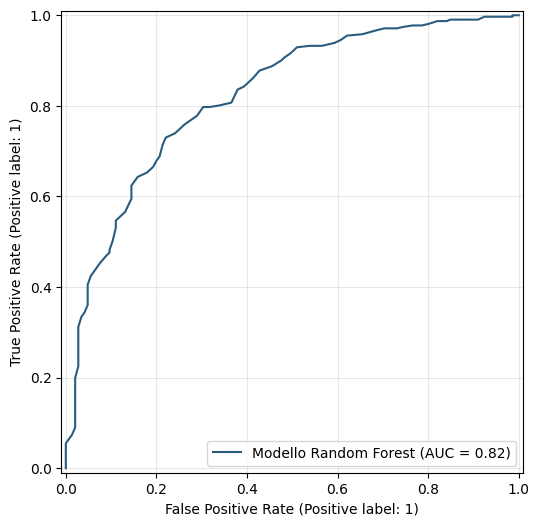

In [ ]:
# 3. Grafico(By me)

fig, ax = plt.subplots(figsize=(8,6))

# Proietto il modello ROC nel grafico
RocCurveDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test,
    ax=ax,
    color = "#295C7E",
    name = 'Modello Random Forest'
)
plt.grid(True, alpha = 0.3 )


## Dzgroup

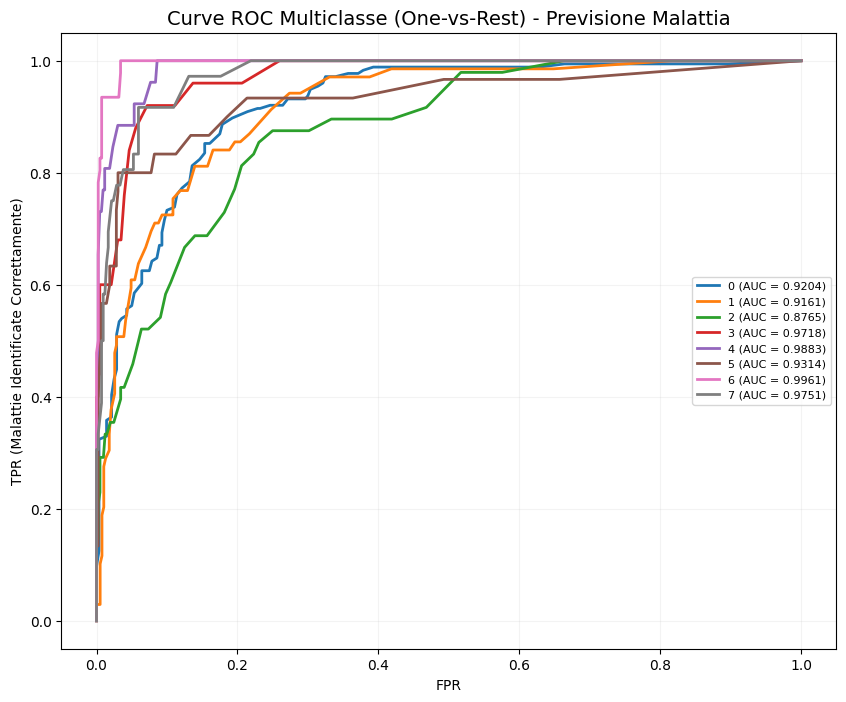

: 

In [ ]:
# DZGROUP
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
#  Cosa significa in parole povere? La Curva ROC "pura" funziona solo quando le risposte sono due (Sì/No, Vivo/Morto).
#  Visto che qui abbiamo tante malattie diverse, il metodo One-vs-Rest scompone il problema e fa finta che sia binario, calcolando una curva per ogni singola malattia. ==> usiamo label_binarize che trasforma la colonna di malattie in tante colonne 0/1

#Codifica y_test
y_test_encoded = label_encoder.transform(y_test)
#Probabilità
y_prob_multi = best_rf_multi.predict_proba(X_test)

# Estraggo la lista delle malattie che il modello ha imparato a riconoscere
classi = best_rf_multi.classes_

# Affinché la roc funzioni, bisogna binarizzare le etichette del test
y_multiclasses = label_binarize(y_test_encoded, classes = classi)
n_classi = y_multiclasses.shape[1]

# Grafico
fig, ax = plt.subplots(figsize=(10, 8))

# Creiamo un for che scorra tutte le classi in cui calcoliamo la ROC per ogni singola classe
for i in range(n_classi):
    fpr, tpr, _ = roc_curve(y_multiclasses[:, i], y_prob_multi[:, i])
    roc_auc = auc(fpr, tpr)
    nome_malattia = classi[i]
    ax.plot(fpr, tpr, lw = 2, label = f"{nome_malattia} (AUC = {roc_auc:.4f})")

# 6. Dettagli estetici
plt.title("Curve ROC Multiclasse (One-vs-Rest) - Previsione Malattia", fontsize=14)
plt.xlabel("FPR")
plt.ylabel("TPR (Malattie Identificate Correttamente)")
plt.legend(loc="center right", fontsize=8)
plt.grid(True, alpha=0.15)

plt.show()

### Aps

In [19]:
# REGRESSORE
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# (Attenzione: si usa .predict() e non .predict_proba() perché vogliamo il numero esatto, non la probabilità!)
y_pred = best_rf_reg.predict(X_test_aggiornato)

# Calcolo metrica R2
r2 = r2_score(y_test, y_pred)
print(r2)

0.748380779971


In [ ]:
#grafico
import matplotlib.pyplot as plt

# Prepariamo il grafico
fig, ax = plt.subplots(figsize=(8, 6))

# Disegniamo i punti: Asse X = Valori Reali, Asse Y = Valori Predetti
ax.scatter(y_test, y_pred, alpha=0.5, color='#295C7E', label="Pazienti")

# Calcoliamo i limiti per tracciare la diagonale rossa (la linea della perfezione)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# Tracciamo la linea diagonale tratteggiata
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Previsione Perfetta (R2 = 1.0)")

# Dettagli estetici del grafico
ax.set_title("Valutazione Regressore: Valori Reali vs Predetti ('aps')", fontsize=14)
ax.set_xlabel("Valori Reali (Punteggio APS Effettivo)")
ax.set_ylabel("Valori Predetti dal Modello Random Forest")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Mostriamo il grafico
plt.show()

 Si noti che gli iperparametri indicati potrebbero non essere quelli ottimali perché il
modello di addestri bene. Opzionalmente si discuta se non sia il caso di condizionare il
modello ad altri iperparametri e si conducano le relative prove.




TIPS PROF:
L'ANALISI delle tre task verrà effettuata separatamente, perché le feature non si sistemano con una sola analisi(possono ovviamente variare).

La GridSearch conserva lo score per ogni modello ==> quindi dagli iperparametri si deve trarre una conclusione come ad esempio se crescono, o cosa succede se su applica una configurazione differente etc..